# Introduction

The purpose of this notebook is to work through the stock market related data to figure out what data exists and how we can combine everything.

The pipeline for stock data has not yet been started. There are two files: `all_stocks_5yr.csv` and `sector_industry.csv`. Discussion of data acquisition will be included for documentation. There's a third, much larger dataset, `stock_dataset.csv`, from hugging face that will also be included.

Essentially, the goal of this exploration is to label existing data, figure out date ranges, and start looking for the "useful" variables.

## Setup

We will be using common data science libraries listed below. Additionally, we plan to use `plotnine` as the data viz library to adhere to the grammar of graphics.

In [1]:
import pandas as pd
from plotnine import *

import re

from sector_study.config import PROCESSED_DATA_DIR

print("setup complete!")

2025-10-21 15:28:27.756 | INFO     | sector_study.config:<module>:27 - PROJ_ROOT path is: C:\Users\cjejc\git\sector_study


setup complete!


## Data

All acquired stock data is included in this notebook. The stock data part of the pipeline is still underdeveloped, so this notebook will also demonstrate how the pipeline is programmed.

There are three data sources containing stock data. `all_stocks_5yr.csv` is from [camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500) on Kaggle. It contains data for all S&P 500 stocks over a five year period. `sector_industry_info.csv` and `stock_dataset.csv` are from HuggingFace, [yeong-hwan/ticker-sector-industry](https://huggingface.co/datasets/yeong-hwan/ticker-sector-industry) and [Adilbai/stock-dataset](https://huggingface.co/datasets/Adilbai/stock-dataset) respectively. `sector_industry_info.csv` is a ticker-industry-sector lookup table to be used for labeling observations in the other two files. `stock_dataset.csv` also spans 5 years and contains daily observations on the S&P 500 stocks, but I'm not yet sure if the span overlaps with `all_stocks_5yr.csv`. However, `stock_dataset.csv` contains 73 variables per observation, so maybe the granularity of information is better or worse.

This EDA is being preformed after cleaning and combining the datasets. All datasets have been combined and the combined data resides in the processed data directory of this project under `stocks.csv`.

In [2]:
stocks = pd.read_csv(PROCESSED_DATA_DIR.joinpath("stocks.csv"))

In [3]:
print(f"{stocks.shape}\n{stocks.columns}\n")

(1067853, 10)
Index(['date', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'source',
       'sector', 'industry'],
      dtype='object')



So, I didn't keep most of the 73 variables when everything was combined, but the cleaned original datasets are all still available in the raw data directory. `'sector'` and `'industry'` have been applied.

The dataset is over 1,000,000 rows!

# Exploration

## Time Analysis

In [36]:
stocks["date"] = pd.to_datetime(stocks["date"])
print(stocks["date"].min())
print(stocks["date"].max())

2013-02-08 00:00:00+00:00
2025-06-27 04:00:00+00:00


Since each dataset is 5 years, we know that Feb 2018 -- Jun 2020 has no data, as shown below.

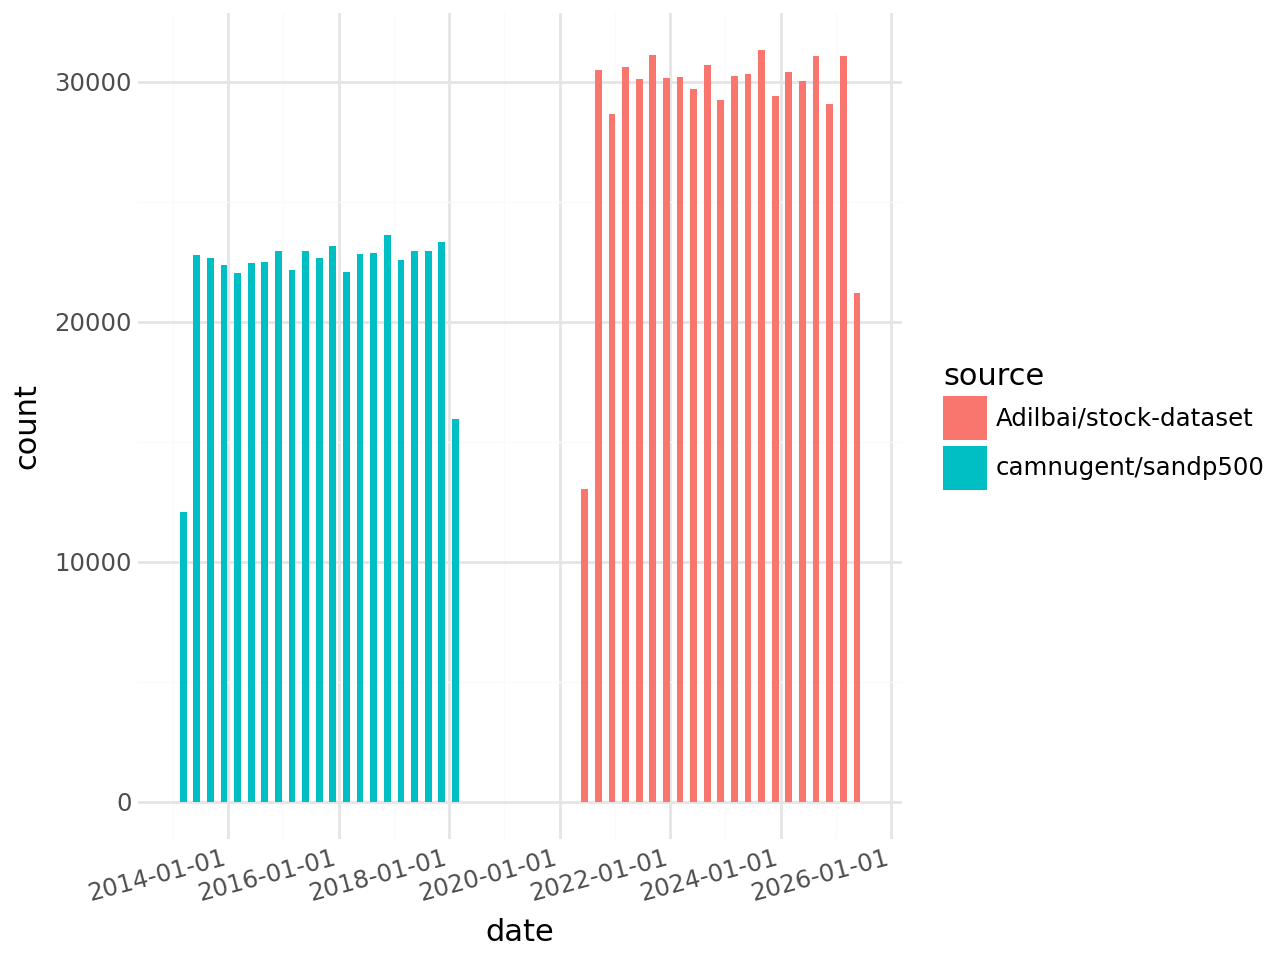

In [44]:
(
  ggplot(stocks, aes(x="date", fill="source"))
  + theme_minimal()
  + geom_histogram(binwidth=90, position="dodge")
  + theme(axis_text_x = element_text(angle = 15, hjust = 1, vjust = 1))
)

Above is a histogram of the date variable, where the bars are colored according to the data source. We can confirm that the two datasets have no time overlap and that there is about a two year gap between the two datasets. We also know that the Adilbai (red) dataset comes after the camnugent (blue) dataset, in case that matters during analysis.

Perhaps finding a dataset for this time period would be insightful. After all, the COVID panic happened in the last few months of 2019 and the first few months of 2020. I think it's odd that the two datasets don't have equal counts. The S&P 500 is supposed to have investments in a fixed amount (500) of stocks, right?

## The Normalcy of the S&P 500

Let's start looking at some univariate distributions by observing the opening prices of stocks

In [5]:
stocks.describe()

,open,high,low,close,volume
count,1.067845e+06,1.067848e+06,1.067848e+06,1.067853e+06,1.067853e+06
mean,1.338230e+02,1.352973e+02,1.323297e+02,1.338431e+02,5.556264e+06
std,2.748470e+02,2.780851e+02,2.716970e+02,2.749032e+02,1.892530e+07
min,1.620000e+00,1.690000e+00,1.610000e+00,1.620000e+00,0.000000e+00
25%,4.707000e+01,4.756945e+01,4.658000e+01,4.709000e+01,1.047698e+06
50%,7.885000e+01,7.962760e+01,7.802939e+01,7.885000e+01,2.160200e+06
75%,1.431200e+02,1.445900e+02,1.415634e+02,1.431125e+02,4.847300e+06
max,9.914170e+03,9.964770e+03,9.794000e+03,9.924400e+03,1.543911e+09


Given that standard deviation is larger than the mean, some normalization might be required.

In [ ]:
import numpy as np

pd.Series(np.log10(stocks["open"])).describe()

count    1.067845e+06
mean     4.424288e+00
std      8.875107e-01
min      4.824261e-01
25%      3.851636e+00
50%      4.367547e+00
75%      4.963683e+00
max      9.201720e+00
Name: open, dtype: float64

That looks like it fixed things. This wasn't a lucky guess, I've already done some EDA on the raw datasets: I knew the transformation was logarithmic.

c:\Users\cjejc\git\sector_study\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
c:\Users\cjejc\git\sector_study\.venv\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 5 rows containing non-finite values.


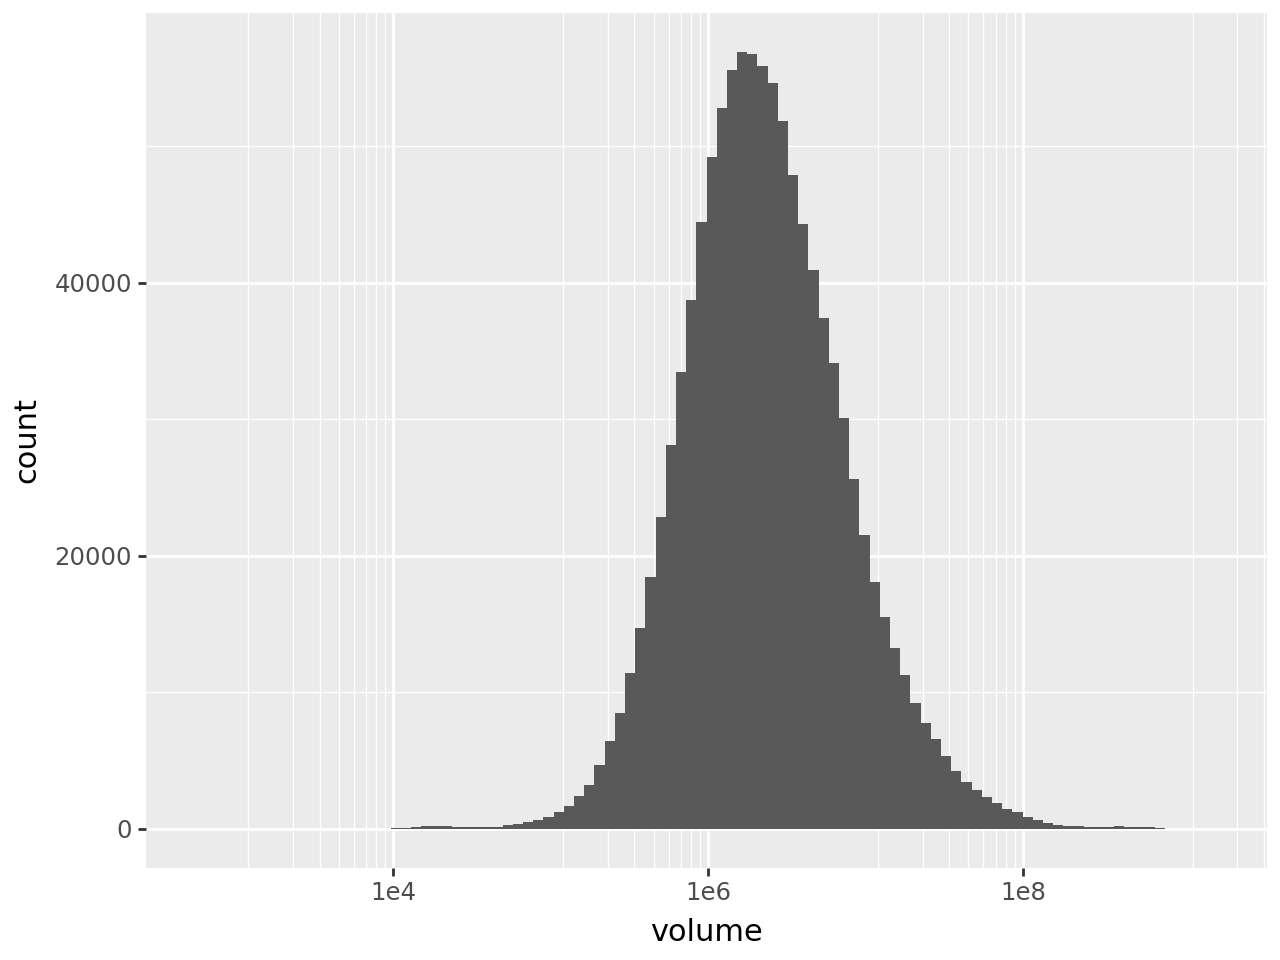

In [53]:
(
  ggplot(stocks)
  + geom_histogram(aes(x = "volume"), bins=100)
  + scale_x_log10()
)

I'm not sure what to say. I suppose it makes sense that the logarithm of volume frequency has a Gaussian distribution.

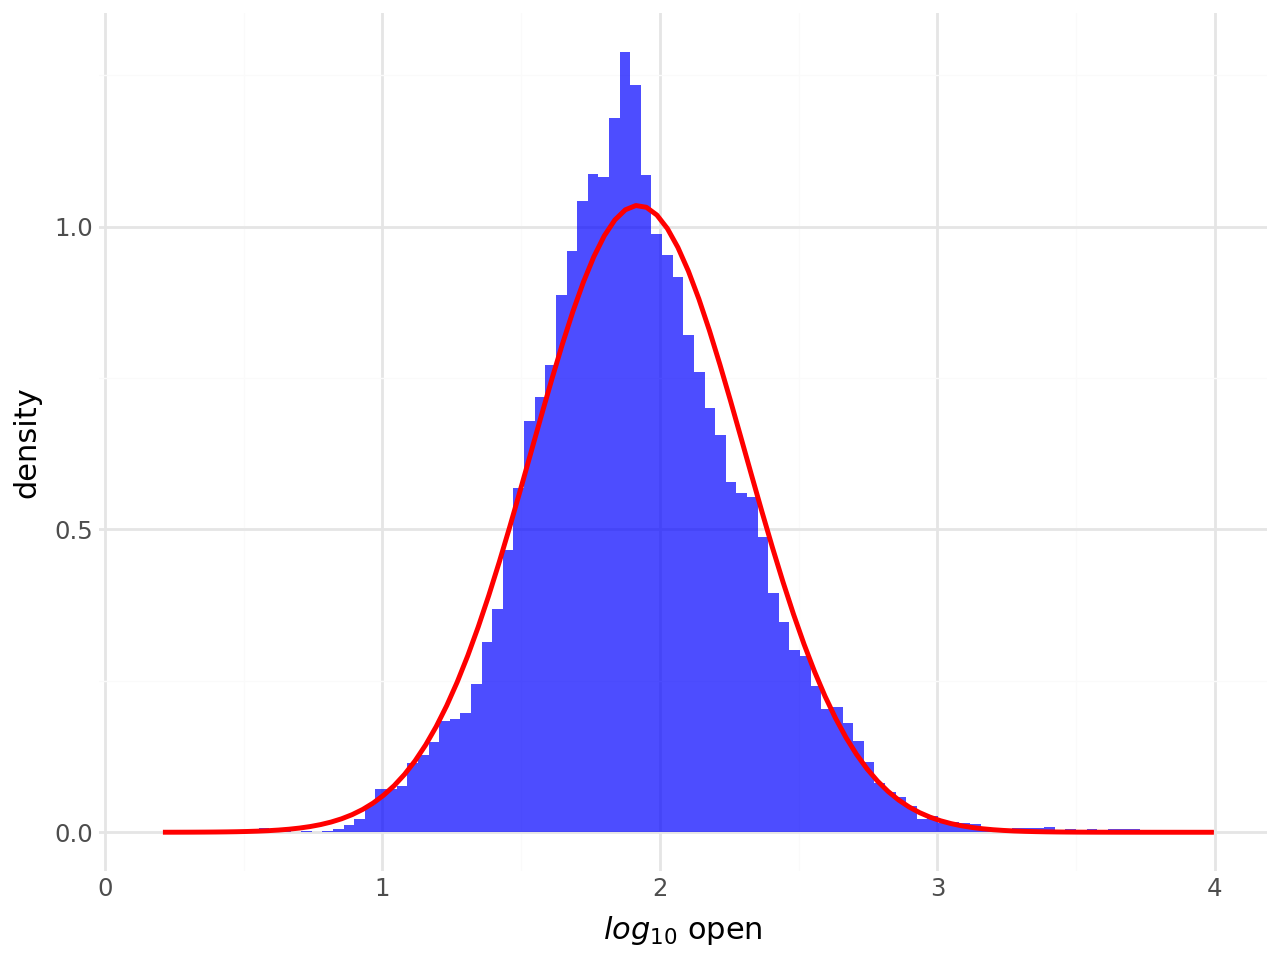

In [7]:
from scipy.stats import norm

df = stocks[stocks["open"].notna()][["open"]]
df['log_open'] = np.log10(df["open"])

mean = df["log_open"].mean()
std = df["log_open"].std()

(
  ggplot(df, aes(x="log_open"))
  + theme_minimal()
  + geom_histogram(
      aes(y=after_stat("density")),
        bins=100,
        fill='blue',
        alpha = 0.7
      )
  + stat_function(
      fun=norm.pdf, args={"loc": mean, "scale": std},
      color='r',
      size=1
    )
  + labs(
    x = "$log_{10}$ open",
    y = "density"
  )
)

## Sector Breakdown

This histogram is actually extremely interesting. This is a collective of new and old S&P 500 data. So the mean being around 2 suggests that the average value of the individual stock in S&P 500 is just around $10^2=100$. Further, the graph is very close to the normal distribution (red). This does not hold through sector breakdown.

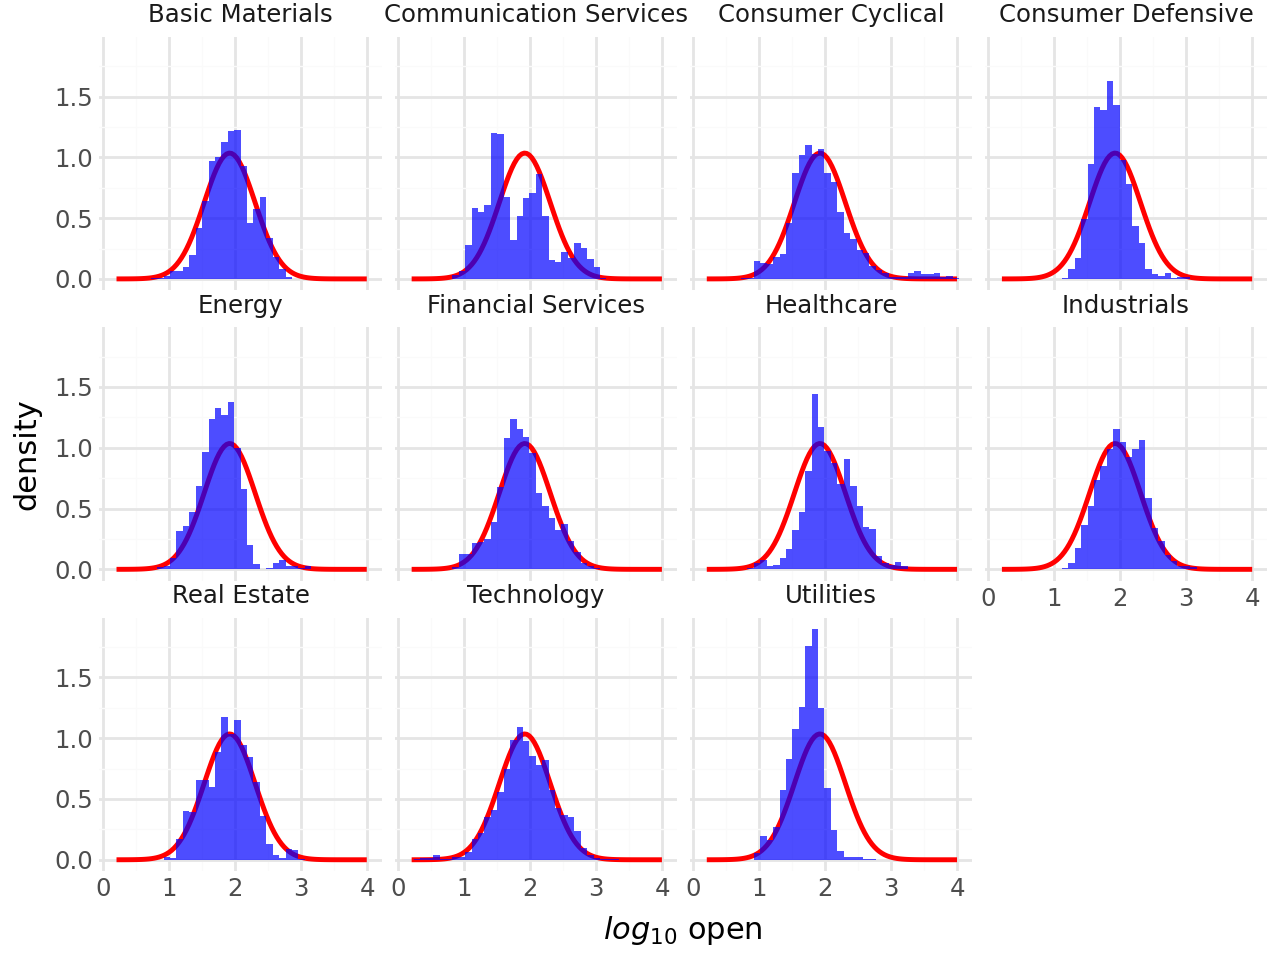

In [27]:
df["sector"] = stocks["sector"]
df["source"] = stocks["source"]

(
  ggplot(df, aes(x = "log_open"))
  + theme_minimal()
  + facet_wrap("sector")
  + stat_function(
      fun=norm.pdf, args={"loc": mean, "scale": std},
      color='r',
      size=1,
    )
  + geom_histogram(
      aes(y=after_stat("density")),
      bins=40,
      position="dodge",
      fill='b',
      alpha=0.7
    )
  + labs(
      x = "$log_{10}$ open",
      y = "density"
    )
)

Take Communication Services for example, there's a trimodal distribution going on. We can further break a sector down.

### Explaining Sector Components

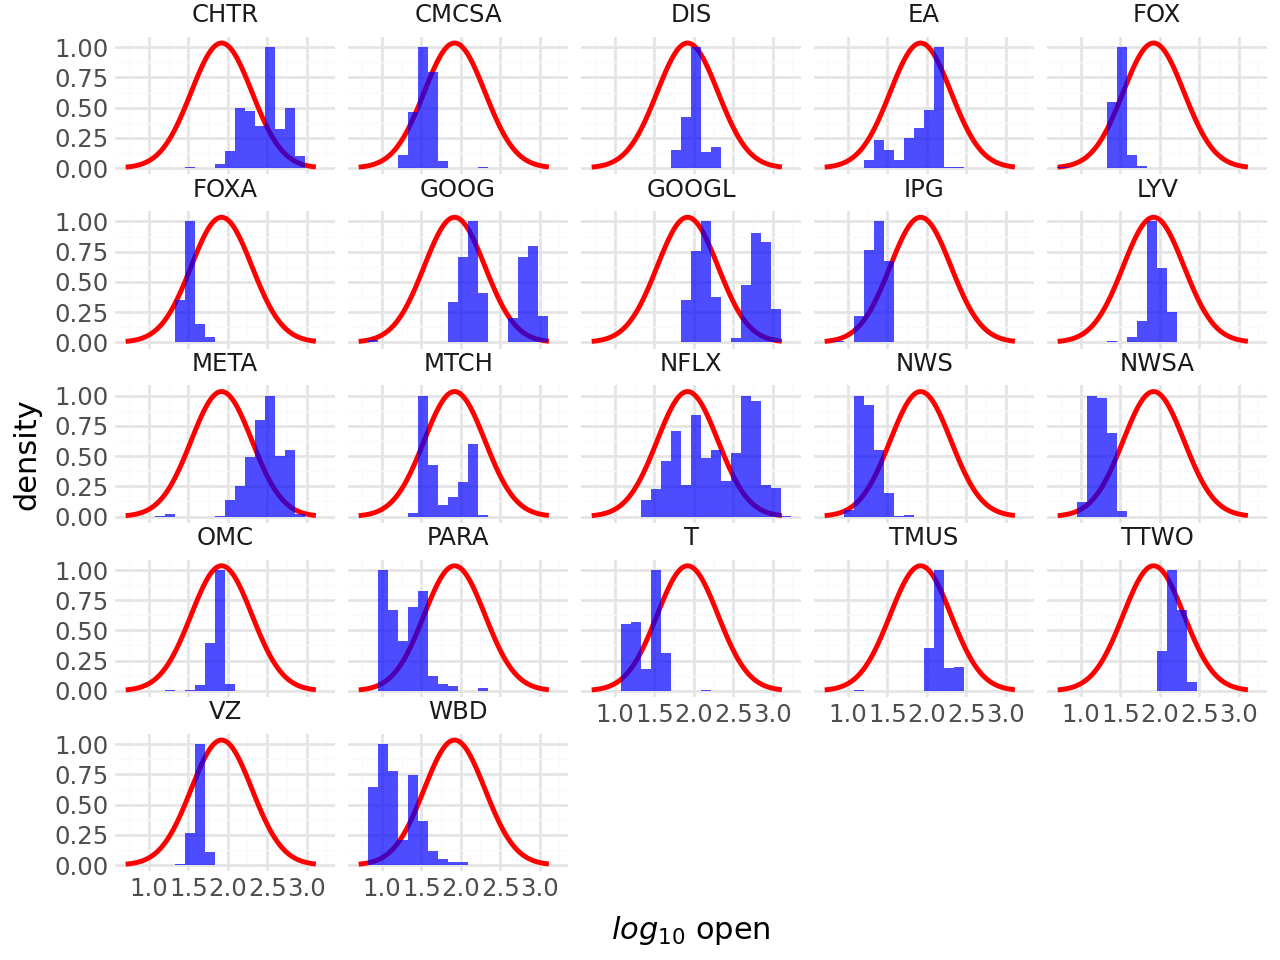

In [28]:
df["industry"] = stocks["industry"]
df["ticker"] = stocks["ticker"]

comsec_subset = df[df["sector"] == "Communication Services"]

(
  ggplot(comsec_subset, aes(x = "log_open"))
  + theme_minimal()
  + facet_wrap("ticker")
  + stat_function(
      fun=norm.pdf, args={"loc": mean, "scale": std},
      color='r',
      size=1,
    )
  + geom_histogram(
      aes(y=after_stat("ndensity")),
      bins=20,
      position="dodge",
      fill='b',
      alpha=0.7
    )
  + labs(
      x = "$log_{10}$ open",
      y = "density"
    )
)

The small multiples are normalized density graphs of each company making up the Communication Services sector. There are three common shapes, the verticle lines (AFL), a dense/pointy Gaussian distribution (DIS), and a bimodal distribution (GOOGL). Verticle lines, like AFL, indicate that there is little fluctuation in the stock while the wide NFLX graph represents significant fluctuation in the *order of magnitude* of stock value -- fluctuations so large that adding or removing zeros are involved! None of these charts exactly fit the overall normal distribution anymore.

### Effects of COVID-19

Recall, the combination of these charts forms a trimodal distribution. The largest mode is the left-most mode, which I think can be attributed to the majority of pointy distributions falling left of the mean. The remaining bimodal distrbution represents the impact of the 2020 Shutdown on large corporations, shown below.

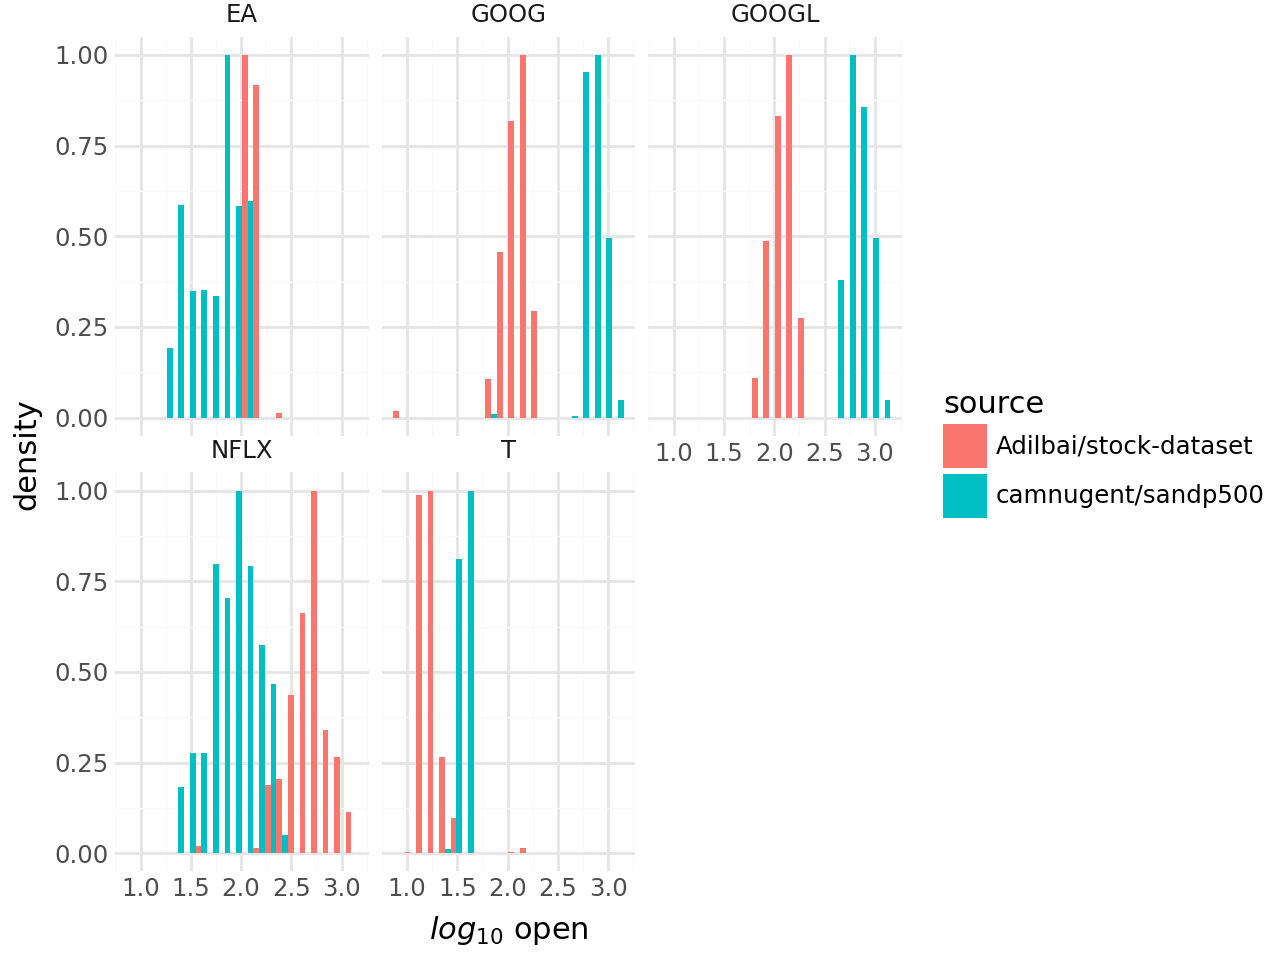

In [47]:
interested_tickers = [
  "GOOG", "GOOGL", "NFLX", "T", "EA"
]

bimodal_companies = df[df["ticker"].isin(interested_tickers)]

(
  ggplot(bimodal_companies, aes(x = "log_open"))
  + theme_minimal()
  + facet_wrap("ticker")
  + geom_histogram(
      aes(y=after_stat("ndensity"), fill="source"),
      bins=20,
      position="dodge",
    )
  + labs(
      x = "$log_{10}$ open",
      y = "density"
    )
)

The red dataset is the post-COVID dataset and the blue is the pre-COVID dataset. When the red is on the left of the blue the stock's value is less now. When red is on the right the stock's value has increased over time. So Google and Tesla stocks have fallen since 2015, but EA and Netflix stocks have risen. Netflix's stock is about ten times more valuable after the COVID shutdown. On the other hand, Google stock is about ten times less valuable after COVID happened. I predicted that the colors would be on the same side in each chart, but that isn't the case. Instead, a better conclusion may be that these stocks were volatile during COVID.

### Recap

Individual companies have dense, not-exactly-normal (opening) prices because the opening prices are _not independent_. However, aggregation across an entire sector of companies *does* generally produce a kind-of normal distribution. Aggregation of sectors creates a fairly normal distribution representing a normal relation between the frequency and the log of stock price within the index fund.

## Multivariate Numeric Analysis

The previous section is a thinly-guised multivariate analysis with one numeric and multiple (heirarchical) categorical variables. This section will be a deep dive into numeric analysis.

c:\Users\cjejc\git\sector_study\.venv\Lib\site-packages\plotnine\layer.py:372: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


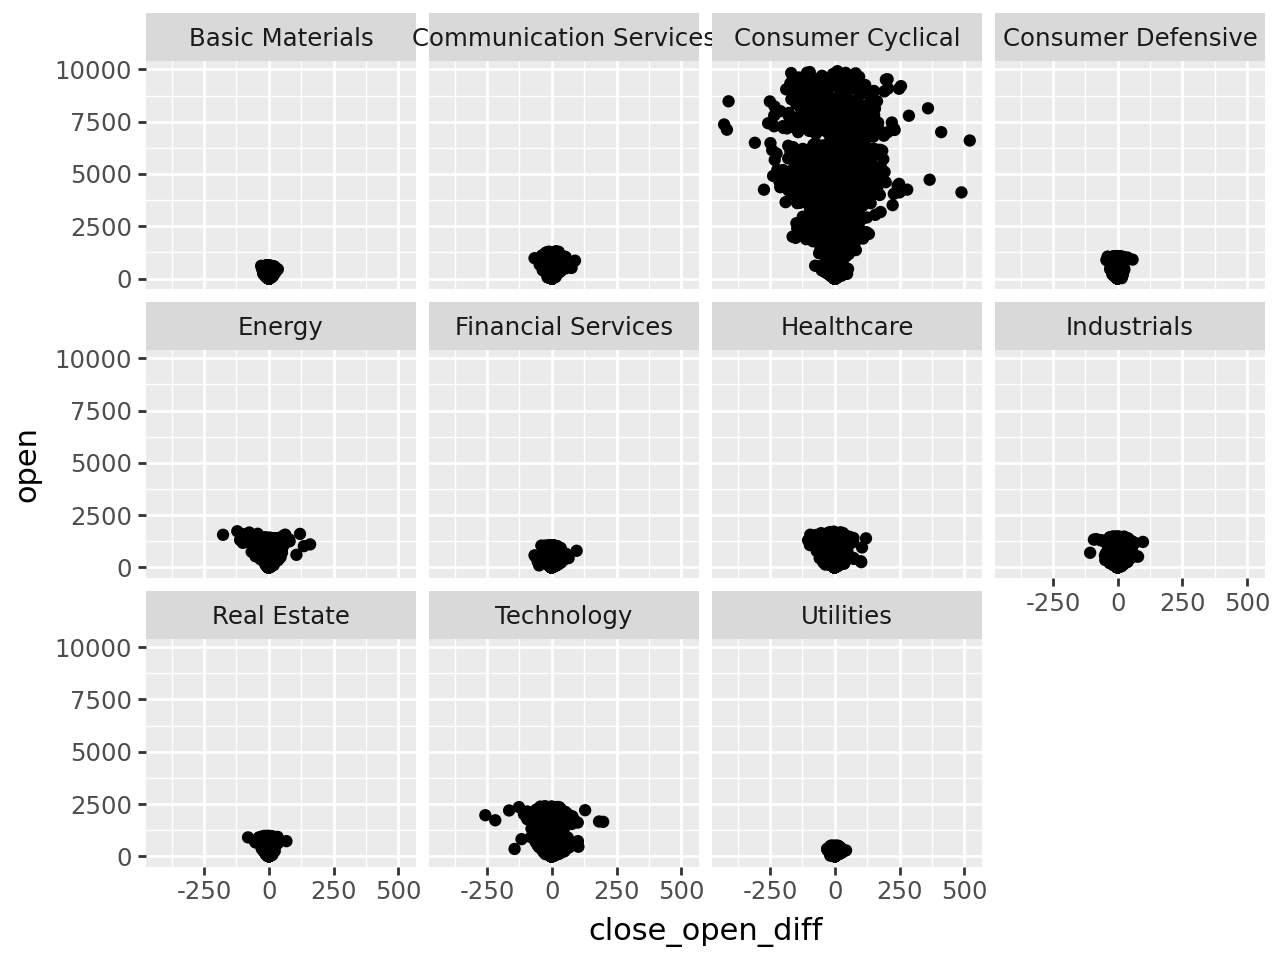

In [66]:
stocks["close_open_diff"] = stocks["close"] - stocks["open"]

(
  ggplot(stocks)
  + geom_point(aes(x = "close_open_diff", y = "open"))
  + facet_wrap("sector")
)

c:\Users\cjejc\git\sector_study\.venv\Lib\site-packages\plotnine\layer.py:372: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


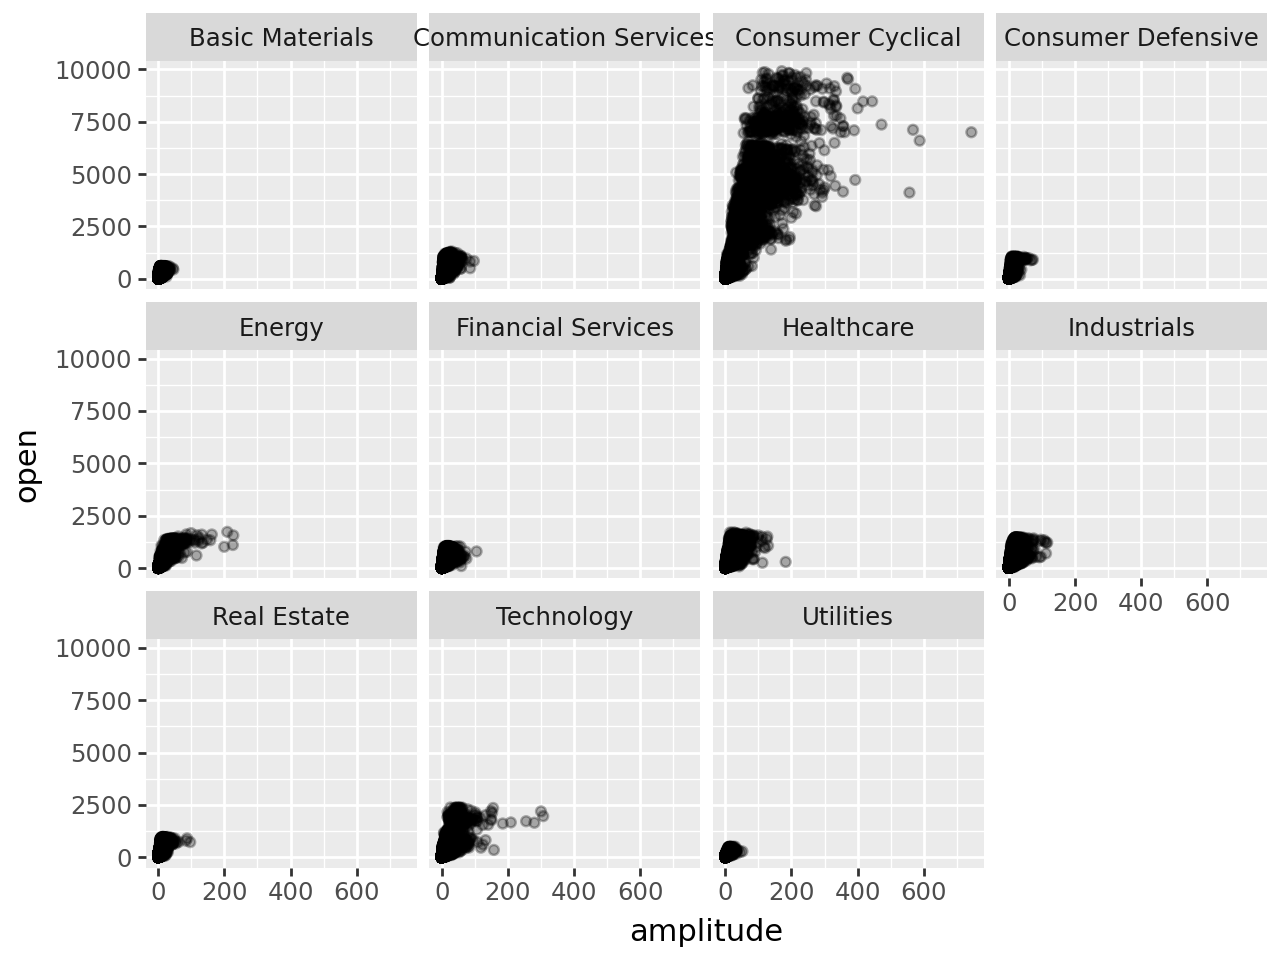

In [65]:
stocks["amplitude"] = stocks["high"] - stocks["low"]

(
  ggplot(stocks)
  + geom_point(aes(x = "amplitude", y = "open"), alpha=0.3)
  + facet_wrap("sector")
)

# Takeaways

The important part of [Sector Breakdown](#sector-breakdown) is how the breakdown occurs, and at what point the Gaussian curves break down. This information will be useful when extracting features from headlines. For example, if a model clusters the terms "Search Engine", "Google", and "Curation" together, we know that cluster probably represents the Communication Services sector.

We see that the [Time Analysis](#time-analysis) section helps describe some anomalies within the [Sector Breakdown](#sector-breakdown), but the question should be if we want to normalize this with time/source features during model training. I think using time might be okay, but source definetly needs to be left out -- the source variable was expresly included for EDA.